The dataset was used in the 1983 American Statistical Association Exposition. The data concerns city-cycle fuel consumption in miles per gallon, to be predicted in terms of 2 multivalued discrete and 4 continuous variables. 

Dataset: cars-dataset.csvView in a new window

Attribute Information:

Car Name – Name of the car

Cyl – No of cylinders in the car – Multivalued discrete

Disp – Displacement – continuous

Hp – Horsepower – continuous

Wt – Weight – continuous

Acc – Acceleration – continuous

Yr – Model of the car – Multivalued discrete

Mpg - Miles per gallon - continuous



Total points: 30

Steps to follow:

1. Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points
2. Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points
3. Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)
4. Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)



In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
%matplotlib inline

# 1. Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points


In [3]:
# reading the CSV file into pandas dataframe
df = pd.read_csv("cars-dataset.csv", na_values=['?'])

In [4]:
df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130.0,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165.0,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150.0,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150.0,3433,12.0,70,16.0
4,ford torino,8,302.0,140.0,3449,10.5,70,17.0


In [5]:
#Check for any null or nan values
df.isnull().values.any(), df.isna().values.any()

(True, True)

In [6]:
df.isnull().sum()

car name    0
cyl         0
disp        0
hp          6
wt          0
acc         0
yr          0
mpg         0
dtype: int64

In [7]:
# 'hp' has something other than numbers.
#median = df['hp'].median()
#df['hp'].fillna(median, inplace=True)
#Check
#df.isnull().sum()

In [8]:
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
car name    392 non-null object
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null float64
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 27.6+ KB


In [10]:
# 'hp' has something other than numbers.

In [11]:
df.describe()

,cyl,disp,hp,wt,acc,yr,mpg
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,23.445918
std,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,7.805007
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,17.000000
50%,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,22.750000
75%,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,29.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,46.600000


# 2. Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points

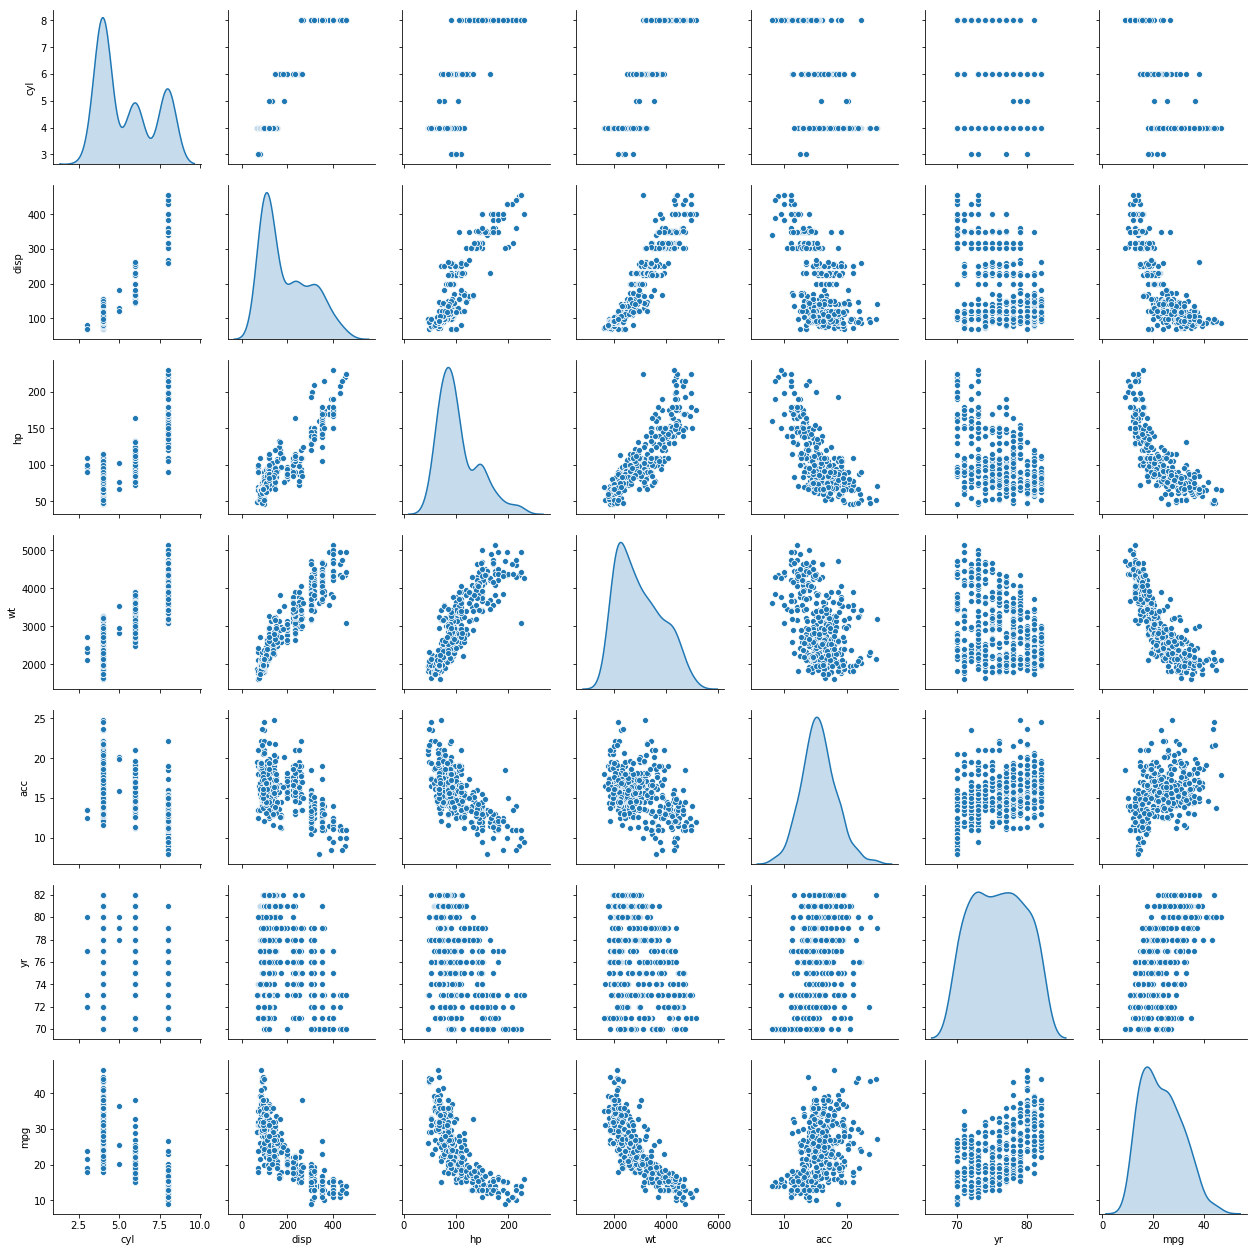

In [12]:
#importing seaborn for statistical plots
import seaborn as sns
sns.pairplot(df, diag_kind='kde')

## Inference
From the pairplot we can infer that there will be about 3-5 clusters which can be formed.

# 3. Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)


In [13]:
from scipy.stats import zscore

In [14]:
X = df.drop(['car name'], axis=1)
X.head()

,cyl,disp,hp,wt,acc,yr,mpg
0,8,307.0,130.0,3504,12.0,70,18.0
1,8,350.0,165.0,3693,11.5,70,15.0
2,8,318.0,150.0,3436,11.0,70,18.0
3,8,304.0,150.0,3433,12.0,70,16.0
4,8,302.0,140.0,3449,10.5,70,17.0


In [53]:
df_z = X.apply(zscore)
df_z.head()

,cyl,disp,hp,wt,acc,yr,mpg
0,1.483947,1.077290,0.664133,0.620540,-1.285258,-1.625315,-0.698638
1,1.483947,1.488732,1.574594,0.843334,-1.466724,-1.625315,-1.083498
2,1.483947,1.182542,1.184397,0.540382,-1.648189,-1.625315,-0.698638
3,1.483947,1.048584,1.184397,0.536845,-1.285258,-1.625315,-0.955212
4,1.483947,1.029447,0.924265,0.555706,-1.829655,-1.625315,-0.826925


In [16]:
from sklearn.cluster import KMeans

In [17]:
# Let us check optimal number of clusters-
cluster_range = range( 1, 15)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
cluster_sil_scores = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(df_z)
  labels = clusters.labels_                     # capture the cluster lables
  centroids = clusters.cluster_centers_         # capture the centroids
  cluster_errors.append( clusters.inertia_ )    # capture the intertia

# combine the cluster_range and cluster_errors into a dataframe by combining them
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors} )
clusters_df[0:15]

,num_clusters,cluster_errors
0,1,2744.000000
1,2,1272.900760
2,3,928.617487
3,4,725.349462
4,5,654.945627
5,6,586.073426
6,7,534.423111
7,8,489.633074
8,9,454.299640
9,10,415.391236


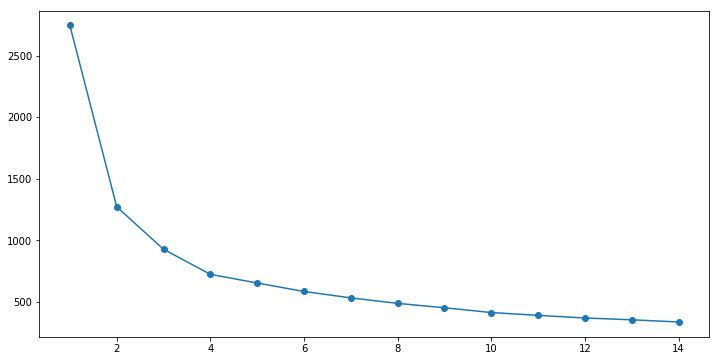

In [18]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [19]:
# Let us first start with K = 3
final_model=KMeans(4)
final_model.fit(df_z)
#prediction=final_model.predict(df_z)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

In [20]:
prediction=final_model.predict(df_z)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f650faa6cc0>,
      dtype=object)

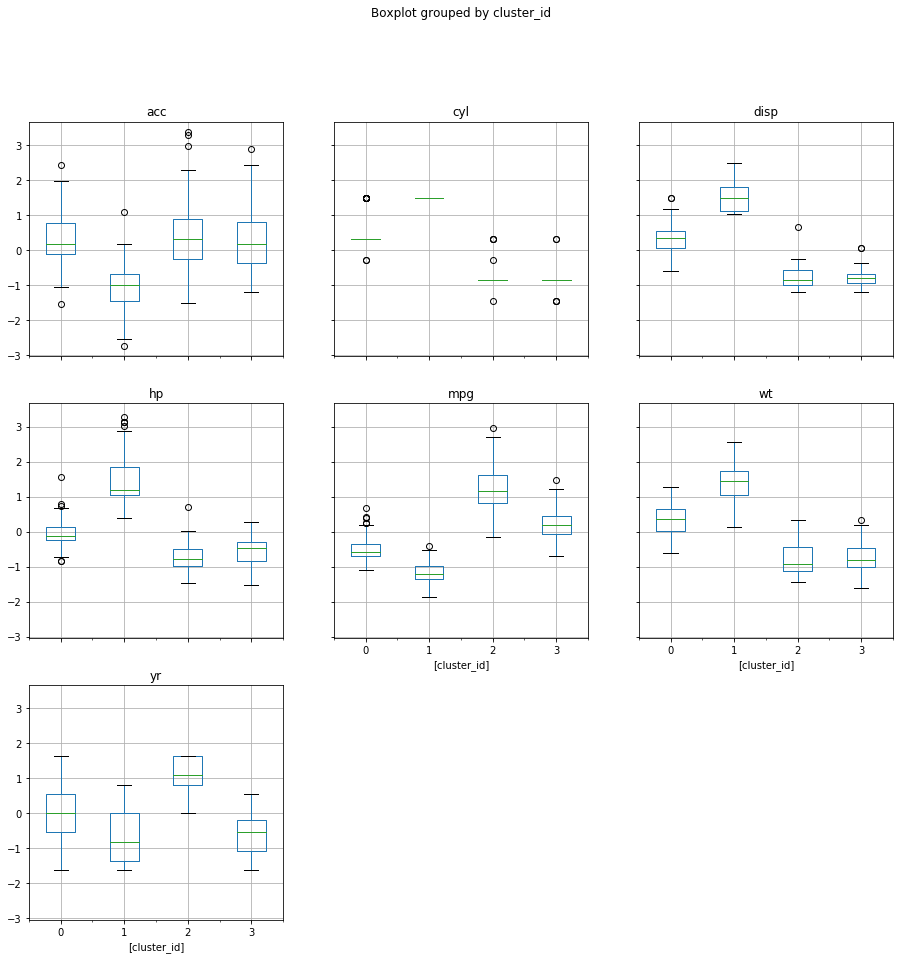

In [54]:
centroids = final_model.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns = list(df_z) )
#Append the prediction 
cars_z_group4_df = df_z.copy()
cars_z_group4_df["cluster_id"] = prediction
cars_z_group4_df.boxplot(by = 'cluster_id',  layout=(4,3), figsize=(15, 20))

### Inference
The overlap is less for 4 clusters, so i guess, we can go ahead with k=4

In [57]:
df_z['class_predicted'] = prediction
df_z.head()

,cyl,disp,hp,wt,acc,yr,mpg,class_predicted
0,1.483947,1.077290,0.664133,0.620540,-1.285258,-1.625315,-0.698638,1
1,1.483947,1.488732,1.574594,0.843334,-1.466724,-1.625315,-1.083498,1
2,1.483947,1.182542,1.184397,0.540382,-1.648189,-1.625315,-0.698638,1
3,1.483947,1.048584,1.184397,0.536845,-1.285258,-1.625315,-0.955212,1
4,1.483947,1.029447,0.924265,0.555706,-1.829655,-1.625315,-0.826925,1


In [58]:
df_z.groupby(["class_predicted"]).count()

,cyl,disp,hp,wt,acc,yr,mpg
class_predicted,,,,,,,
0,89,89,89,89,89,89,89
1,94,94,94,94,94,94,94
2,109,109,109,109,109,109,109
3,100,100,100,100,100,100,100


In [59]:
x = df_z['class_predicted'].value_counts()
x

2    109
3    100
1     94
0     89
Name: class_predicted, dtype: int64

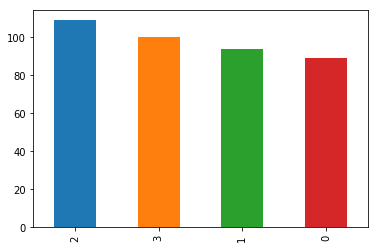

In [60]:
x.plot.bar()

/usr/lib/python3/dist-packages/statsmodels/nonparametric/kde.py:494: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X,a,b,gridsize)/(delta*nobs)
/usr/lib/python3/dist-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


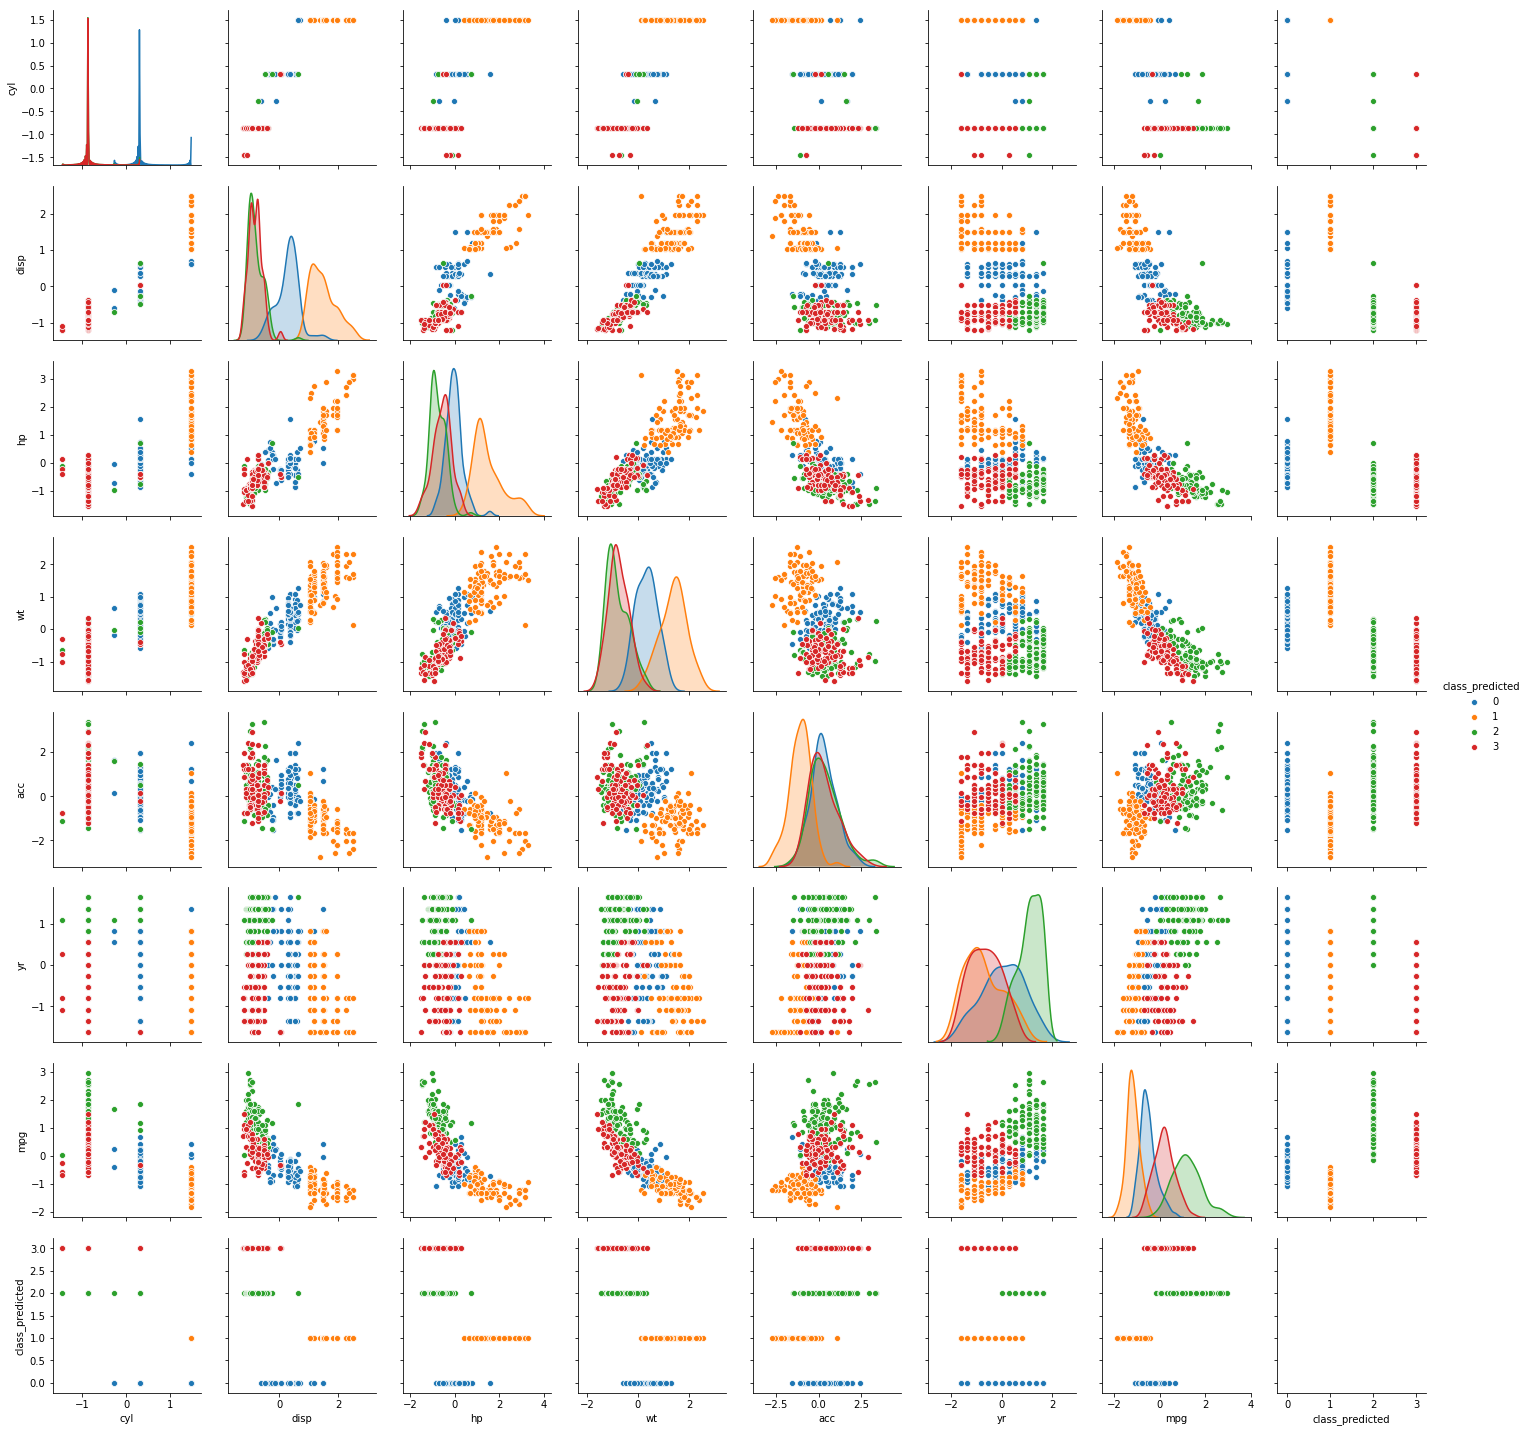

In [61]:
sns.pairplot(df_z, diag_kind='kde', hue='class_predicted')

## Inference
This shows the overall distribution across each features based on the clustered values.

# 4. Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [38]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def model_evaluate(df_in):
    df_in = df_in.copy()
    regr = linear_model.LinearRegression()
    test_size = 0.30 # taking 70:30 training and test set
    seed = 0  # Random numbmer seeding for reapeatability of the code
    
    X =  df_in.drop(["car name", "mpg"], axis=1)
    y =  df_in.pop("mpg")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    # Train the model using the training sets
    regr.fit(X_train, y_train)

    # Make predictions using the testing set
    y_pred = regr.predict(X_test)

    # The coefficients
    print('Coefficients: \n', regr.coef_)
    # The mean squared error
    mserr = mean_squared_error(y_test, y_pred)
    print("Mean squared error: %.2f" % mserr)
    # Explained variance score: 1 is perfect prediction
    print('Variance score: %.2f' % r2_score(y_test, y_pred))
    return mserr

In [40]:
clusters = np.unique(prediction)
mserr = 0
for i, cluster in enumerate(clusters):
    df_x = df[df_z['class_predicted'] == cluster]
    print("\nCLUSTER ", i, " parameters")
    mserr = mserr + model_evaluate(df_x)
avg_mse = mserr/len(clusters) 
print("\nModel parameters without clustering")
mserr = model_evaluate(df)

print("\nAverage MSE of clustered linear models = ", avg_mse)
print("MSE of model without clustering = ", mserr)


CLUSTER  0  parameters
Coefficients: 
 [ 0.97379024 -0.0018198  -0.01466823 -0.00380546  0.04628882  0.47391712]
Mean squared error: 4.12
Variance score: 0.55

CLUSTER  1  parameters
Coefficients: 
 [ 0.00000000e+00 -9.69242628e-03 -2.21606299e-02 -5.77183414e-04
 -5.90452161e-01  4.07716627e-01]
Mean squared error: 1.73
Variance score: 0.56

CLUSTER  2  parameters
Coefficients: 
 [ 4.5354153  -0.00569705 -0.07683445 -0.00858642  0.37067127  0.71946824]
Mean squared error: 10.91
Variance score: 0.15

CLUSTER  3  parameters
Coefficients: 
 [ 2.88347907 -0.04175833 -0.05449031 -0.00505588 -0.29440718  0.36685958]
Mean squared error: 4.72
Variance score: 0.62

Model parameters without clustering
Coefficients: 
 [-2.83029573e-01  2.05832904e-03 -5.78540877e-04 -6.33461712e-03
  4.81253073e-02  7.20358753e-01]
Mean squared error: 12.41
Variance score: 0.80

Average MSE of clustered linear models =  5.372634258563393
MSE of model without clustering =  12.405564685533596


## Inference
In the clustered data, we can see that 
1. The MSE has reduced compared to the whole model
2. The variance score is less for the clustered models.